In [10]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']
PASSIVE_COLOR = '#4F4F4F'

In [11]:
animals = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']

In [12]:
df = pd.read_csv('../../Source Data Files/Figure 2f.csv')

In [13]:
df

,Unnamed: 0,animal,session,cluster ID,phase,condition,FR modulation
0,0,BS_108,BS_108_1_AC.pickle,2,pre expert,behaving,9.972452
1,1,BS_108,BS_108_1_AC.pickle,8,pre expert,behaving,21.774194
2,2,BS_108,BS_108_1_AC.pickle,9,pre expert,behaving,15.806452
3,3,BS_108,BS_108_1_AC.pickle,34,pre expert,behaving,16.989247
4,4,BS_108,BS_108_2_AC.pickle,2,pre expert,behaving,15.402299
...,...,...,...,...,...,...,...
807,807,TH_234,TH_234_3_passive_AC.pickle,172,3,passive,15.795645
808,808,TH_234,TH_234_3_passive_AC.pickle,183,3,passive,3.577236
809,809,TH_234,TH_234_4_passive_AC.pickle,60,3,passive,3.718593
810,810,TH_234,TH_234_4_passive_AC.pickle,73,3,passive,25.644891


In [25]:
df_beh = df[df['condition']=='behaving']
beh_animals = np.unique(df_beh['animal'])

FR_preearly = []
FR_prelate = []
FR_preexpert = []
FR_postearly = []
FR_postlate = []
FR_postexpert = []
for animal in beh_animals:
    preearly_animal = []
    prelate_animal = []
    preexpert_animal = []
    postearly_animal = []
    postlate_animal = []
    postexpert_animal = []
    for row in df_beh.iloc():
        if row['animal'] != animal:
            continue
        if row['phase'] == 'pre early':
            preearly_animal.append(row['FR modulation'])
        if row['phase'] == 'pre late':
            prelate_animal.append(row['FR modulation'])
        if row['phase'] == 'pre expert':
            preexpert_animal.append(row['FR modulation'])
        if row['phase'] == 'post early':
            postearly_animal.append(row['FR modulation'])
        if row['phase'] == 'post late':
            postlate_animal.append(row['FR modulation'])
        if row['phase'] == 'post expert':
            postexpert_animal.append(row['FR modulation'])
    preearly_animal = np.array(preearly_animal)
    prelate_animal = np.array(prelate_animal)
    preexpert_animal = np.array(preexpert_animal)
    postearly_animal = np.array(postearly_animal)
    postlate_animal = np.array(postlate_animal)
    postexpert_animal = np.array(postexpert_animal)
    
    FR_preearly.append(preearly_animal)
    FR_prelate.append(prelate_animal)
    FR_preexpert.append(preexpert_animal)
    FR_postearly.append(postearly_animal)
    FR_postlate.append(postlate_animal)
    FR_postexpert.append(postexpert_animal)



df_passive = df[df['condition']=='passive']
passive_animals = np.unique(df_passive['animal'])

passive_FR_preearly = []
passive_FR_prelate = []
passive_FR_preexpert = []
passive_FR_postearly = []
passive_FR_postlate = []
passive_FR_postexpert = []
for animal in passive_animals:
    preearly_animal = []
    prelate_animal = []
    preexpert_animal = []
    postearly_animal = []
    postlate_animal = []
    postexpert_animal = []
    for row in df_passive.iloc():
        if row['animal'] != animal:
            continue
        if row['phase'] == '1':
            preearly_animal.append(row['FR modulation'])
        if row['phase'] == '2':
            prelate_animal.append(row['FR modulation'])
        if row['phase'] == '3':
            preexpert_animal.append(row['FR modulation'])
        if row['phase'] == '4':
            postearly_animal.append(row['FR modulation'])
        if row['phase'] == '5':
            postlate_animal.append(row['FR modulation'])
        if row['phase'] == '6':
            postexpert_animal.append(row['FR modulation'])
    preearly_animal = np.array(preearly_animal)
    prelate_animal = np.array(prelate_animal)
    preexpert_animal = np.array(preexpert_animal)
    postearly_animal = np.array(postearly_animal)
    postlate_animal = np.array(postlate_animal)
    postexpert_animal = np.array(postexpert_animal)
    
    passive_FR_preearly.append(preearly_animal)
    passive_FR_prelate.append(prelate_animal)
    passive_FR_preexpert.append(preexpert_animal)
    passive_FR_postearly.append(postearly_animal)
    passive_FR_postlate.append(postlate_animal)
    passive_FR_postexpert.append(postexpert_animal)

mean_pc_NCR = []
sem_pc_NCR = []
for FRmods in [FR_preearly,FR_prelate,FR_preexpert,FR_postearly,FR_postlate,FR_postexpert]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=3.5)
    mean_pc_NCR.append(Mw)
    sem_pc_NCR.append(SEMw)

passive_mean_pc_NCR = []
passive_sem_pc_NCR = []
for FRmods in [passive_FR_preearly,passive_FR_prelate,passive_FR_preexpert,passive_FR_postearly,passive_FR_postlate,passive_FR_postexpert]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=3.5)
    passive_mean_pc_NCR.append(Mw)
    passive_sem_pc_NCR.append(SEMw)


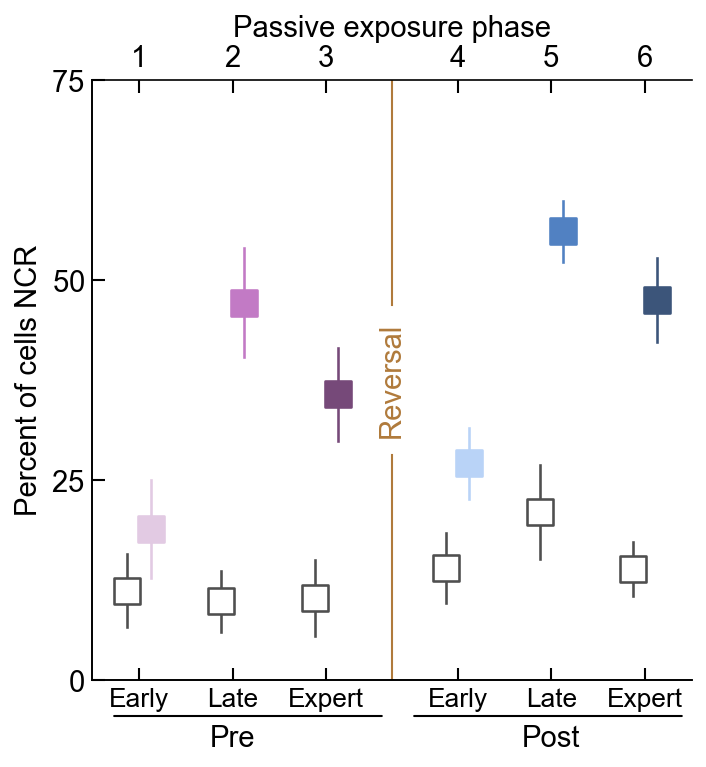

In [23]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

def statsbar(ax,barheight,xpoints,stemheights,text=None,lw=1):
    ymax = ax.get_ylim()[1]
    ymin = ax.get_ylim()[0]
    yrange = ymax-ymin
    ydist = 0.025*yrange
    
    ax.plot([xpoints[0]]*2,[stemheights[0]+ydist,barheight],lw=lw,color='k')
    ax.plot([xpoints[1]]*2,[stemheights[1]+ydist,barheight],lw=lw,color='k')
    ax.plot(xpoints,[barheight]*2,lw=lw,color='k')
    
    if not text is None:
        ax.text(np.mean(xpoints),barheight + ydist,text,horizontalalignment='center',verticalalignment='center')

fig,ax = make_axis_size(4, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.2

################################################################################################################

wid = 0.125#0.175
summary_size=150
summary_width=1.25

for idx,p in zip(range(6),[-1,-1,-1,1,1,1]):
    ax.scatter([idx-wid+p*switch_offset],(passive_mean_pc_NCR[idx]),fc='white',ec=PASSIVE_COLOR,s=summary_size,zorder=10,marker='s',lw=summary_width)
    ax.plot([idx-wid+p*switch_offset,idx-wid+p*switch_offset],[(passive_mean_pc_NCR[idx]-passive_sem_pc_NCR[idx]),(passive_mean_pc_NCR[idx]+passive_sem_pc_NCR[idx])],color=PASSIVE_COLOR,lw=summary_width,zorder=9)
    
    ax.scatter([idx+wid+p*switch_offset],(mean_pc_NCR[idx]),c=PHASE_COLORS[idx],s=summary_size,zorder=10,marker='s',lw=summary_width)
    ax.plot([idx+wid+p*switch_offset,idx+wid+p*switch_offset],[(mean_pc_NCR[idx]-sem_pc_NCR[idx]),(mean_pc_NCR[idx]+sem_pc_NCR[idx])],color=PHASE_COLORS[idx],lw=summary_width,zorder=9)

################################################################################################################

labels = ['Early','Late','Expert','Early','Late','Expert']
labels2 = [1,2,3,4,5,6]

ylab = ax.set_ylabel('Percent of cells NCR')
ax.set_ylim([0,75])
ax.set_yticks([0,25,50,75])
              
ax.set_xlim([-0.5-switch_offset,5.5+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)

ax2 = ax.twiny()
ax2.spines['top'].set_visible(True)
ax2.get_xaxis().set_visible(True)
ax2.set_xlim([-0.5-switch_offset,5.5+switch_offset])
ax2.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax2.set_xticklabels(labels2)
xlab2 = ax2.set_xlabel('Passive exposure phase')

xtick_pos_pre = ax.get_xticks()[1]
xtick_pos_post = ax.get_xticks()[4]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.03, -stdyfrac), xycoords='axes fraction', xytext=(0.49, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.53, -stdyfrac), xycoords='axes fraction', xytext=(0.99, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)
ax2.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
for item in ([ax2.title, ax2.xaxis.label, ax2.yaxis.label] +
    ax2.get_xticklabels() + ax2.get_yticklabels()):
    item.set_fontsize(stdfont)

ax.scatter([], [], ec=PASSIVE_COLOR,fc='white', s=summary_size,lw=summary_width,marker='o',label='passive')
ax.scatter([], [], ec=PASSIVE_COLOR,fc=PASSIVE_COLOR, s=summary_size,lw=summary_width,marker='o',label='behaving')

### Linear
Y = np.mean(ax.get_ylim())
t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([2.5]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
ax.plot([2.5]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

artists = [ylab,t1,t2,xlab2]
# fig.savefig(os.path.join('..','..','Figures','Figure 2f.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [30]:
Xs = [FR_preearly,FR_prelate,FR_preexpert,FR_postearly,FR_postlate,FR_postexpert]
Ys = [passive_FR_preearly,passive_FR_prelate,passive_FR_preexpert,passive_FR_postearly,passive_FR_postlate,passive_FR_postexpert]

pvals = [np.nan]*6
for idx,(X,Y) in enumerate(zip(Xs,Ys)):
    X = np.array(X,dtype='object')
    Y = np.array(Y,dtype='object')
    pvals[idx] = ilep.bootstrap_pc_NCR_test(X,Y,B=25000,CR_NCR_thresh=[3.5])

_,pvals_corr = pg.multicomp(pvals,method='fdr_bh')
print(f'Pre-early  : {pvals_corr[0]}')
print(f'Pre-late   : {pvals_corr[1]}')
print(f'Pre-expert : {pvals_corr[2]}\n')

print(f'Post-early : {pvals_corr[3]}')
print(f'Post-late  : {pvals_corr[4]}')
print(f'Post-expert: {pvals_corr[5]}\n')

Pre-early  : 0.32416
Pre-late   : 0.0
Pre-expert : 0.0014400000000001079

Post-early : 0.057791999999999975
Post-late  : 0.0
Post-expert: 0.0

